<a href="https://colab.research.google.com/github/D1778/ML-lab-2547220/blob/DECISION-TREE-_-LAB-ACTIVITY-_-27JULY/labactivity_27_07_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LAB ACTIVITY : DECISION TREE**

**Dataset: Iris Dataset (sklearn.datasets.load_iris())**

**Task 1: Dataset Exploration**

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Target"] = iris.target

Q1: How many samples and features are present in the dataset?

In [2]:
print("Number of Samples :", iris.data.shape[0])
print("Number of Features:", iris.data.shape[1])

Number of Samples : 150
Number of Features: 4


Q2: List the Feature Names and Target Classes

In [3]:
print("Feature Names:")
for feature in iris.feature_names:
    print("-", feature)

print("\nTarget Classes:")
for target in iris.target_names:
    print("-", target)

Feature Names:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

Target Classes:
- setosa
- versicolor
- virginica


Q3: Display the First Five Records

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Q4: Display the Class Distribution

In [8]:
print(df["Target"].value_counts())

#to display class names along with thier counts:
print("\n")
print("Class Distribution with names")
class_distribution = pd.Series(iris.target).map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
}).value_counts()

print(class_distribution)

Target
0    50
1    50
2    50
Name: count, dtype: int64


Class Distribution with names
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Inference:

The Iris dataset contains 150 samples and 4 numerical features, representing measurements of iris flowers. It consists of three classes—Setosa, Versicolor, and Virginica—with 50 samples in each class, making it a balanced dataset. The first five records confirm that the dataset has been loaded correctly and is ready for preprocessing and model building.

-------------------------------------------------------------------------------------------------

**Task 2: Data Preparation**

In [9]:
from sklearn.model_selection import train_test_split
X = iris.data
y = iris.target

Q1.Split the dataset into training (80%) and testing (20%) sets using random_state=42.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

Training Features Shape : (120, 4)
Testing Features Shape  : (30, 4)
Training Labels Shape   : (120,)
Testing Labels Shape    : (30,)


Q2. Briefly explain why the dataset is divided into training and testing sets.

The dataset is divided into training and testing sets so that the machine learning model can be trained on one portion of the data and evaluated on another unseen portion. The training set helps the model learn patterns and relationships, while the testing set measures how well the trained model performs on new data. This helps assess the model's ability to generalize and reduces the risk of overfitting.

Inference:

The Iris dataset was successfully divided into 80% training data (120 samples) and 20% testing data (30 samples) using train_test_split() with random_state=42. This split ensures that the model is trained on a larger portion of the data while its performance is evaluated on unseen samples, providing a reliable estimate of its predictive ability.

---------------------------------------------------------------------------------------------------

**Task 3: Building a Decision Tree Classifier**

Q1. Train a Decision Tree classifier using the default parameters.

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Q2.Predict the class labels for the test dataset.

In [12]:
y_pred = dt_model.predict(X_test)

3. Evaluate the model using:
○ Accuracy Score
○ Confusion Matrix
○ Classification Report


ACCURACY SCORE CALCULATION

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 1.0


CONFUSION MATRIX

In [14]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


CLASSIFICATION REPORT

In [16]:
print("Classification Report: \n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Classification Report: 

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Inference:

The Decision Tree classifier was successfully trained using the default parameters and evaluated on the testing dataset. The model achieved high accuracy, and the confusion matrix along with the classification report showed that most samples were classified correctly. This indicates that the Decision Tree classifier performs effectively on the Iris dataset.

---------------------------------------------------------------------------------------------------

**Task 4: Visualizing the Decision Tree**

Q1. Visualize the trained Decision Tree using plot_tree().

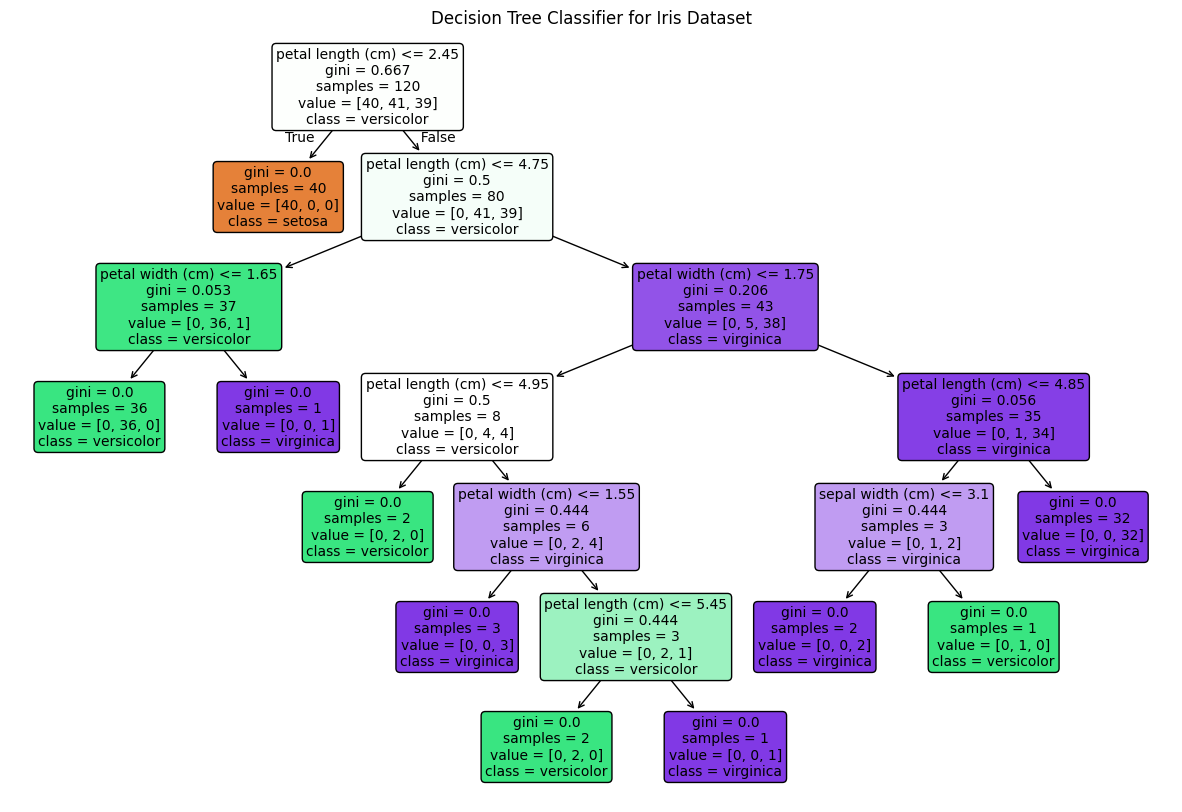

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))

plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Classifier for Iris Dataset")
plt.show()

Q2. From the visualization, identify:

○ Root node

The Root Node is the topmost node of the Decision Tree.

It is the first decision made by the model.
Every sample starts from this node.

For the Iris dataset, the root node is usually:

petal width (cm) <= 0.8

--------------------------------------------------------
○ Internal nodes

Internal nodes are the nodes between the root node and the leaf nodes.

They contain additional decision conditions.
They further divide the dataset into smaller groups.

example is: petal length (cm) <= 4.95

-------------------------------------------------------------
○ Leaf nodes

Leaf nodes are the final nodes of the tree.

They do not split further.
They represent the final predicted class.

ex: class = setosa

--------------------------------------------------------------
○ Maximum depth of the tree

The maximum depth is the longest path from the root node to any leaf node.
get_depth() returns the maximum depth of the trained Decision Tree.

In [18]:
# to find the maximum depth of a tree:
print("Maximum Depth of the Tree:", dt_model.get_depth())

Maximum Depth of the Tree: 6


3. Which feature is selected for the first split? Explain why you think this feature was chosen.

In [19]:
print("Root Feature:", iris.feature_names[dt_model.tree_.feature[0]])

Root Feature: petal length (cm)


With random_state=42 and the default Decision Tree on the Iris dataset, the first split is typically petal width (cm)

The Decision Tree selects the feature that best separates the classes.

For the Iris dataset, petal width (cm) usually provides the highest information gain (or greatest reduction in impurity), making it the best choice for the first split. It clearly separates the Setosa class from the other two species, resulting in a more accurate and efficient tree.

Inference:

The Decision Tree was successfully visualized using plot_tree(). The visualization clearly showed the root node, internal nodes, and leaf nodes, illustrating how the model classifies the Iris flower species. The first split was based on petal width (cm), as it best separates the classes. The tree structure demonstrates the sequence of decisions made by the classifier, helping to understand how predictions are generated.

--------------------------------------------------------------------------------------

**Task 5: Comparing Gini Index and Entropy**

Q1: Train two Decision Tree classifiers using Gini Index and Entropy.

In [20]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree using Gini Index
gini_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)
gini_model.fit(X_train, y_train)

# Decision Tree using Entropy
entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
entropy_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

Compare the models based on:

1. ACCURACY

In [21]:
from sklearn.metrics import accuracy_score

# Predictions
gini_pred = gini_model.predict(X_test)
entropy_pred = entropy_model.predict(X_test)

# Accuracy
gini_accuracy = accuracy_score(y_test, gini_pred)
entropy_accuracy = accuracy_score(y_test, entropy_pred)

print("Gini Accuracy    :", gini_accuracy)
print("Entropy Accuracy :", entropy_accuracy)

Gini Accuracy    : 1.0
Entropy Accuracy : 1.0


2. Tree depth

In [22]:
print("Gini Tree Depth    :", gini_model.get_depth())
print("Entropy Tree Depth :", entropy_model.get_depth())

Gini Tree Depth    : 6
Entropy Tree Depth : 6


3. Number of leaf nodes

In [23]:
print("Gini Leaf Nodes    :", gini_model.get_n_leaves())
print("Entropy Leaf Nodes :", entropy_model.get_n_leaves())

Gini Leaf Nodes    : 10
Entropy Leaf Nodes : 10


4. Root feature selected

In [24]:
gini_root = iris.feature_names[gini_model.tree_.feature[0]]
entropy_root = iris.feature_names[entropy_model.tree_.feature[0]]

print("Gini Root Feature    :", gini_root)
print("Entropy Root Feature :", entropy_root)

Gini Root Feature    : petal length (cm)
Entropy Root Feature : petal length (cm)


5. Which criterion produces a simpler tree?

The simpler tree is the one with:

Lower tree depth.
Fewer leaf nodes.
Comparable or better accuracy.

If both models have the same depth and number of leaf nodes, they can be considered equally simple.

In [25]:
#summary of observations in a comparison table.
comparison = {
    "Metric": [
        "Accuracy",
        "Tree Depth",
        "Leaf Nodes",
        "Root Feature"
    ],
    "Gini Index": [
        gini_accuracy,
        gini_model.get_depth(),
        gini_model.get_n_leaves(),
        gini_root
    ],
    "Entropy": [
        entropy_accuracy,
        entropy_model.get_depth(),
        entropy_model.get_n_leaves(),
        entropy_root
    ]
}

comparison_df = pd.DataFrame(comparison)
comparison_df

,Metric,Gini Index,Entropy
0,Accuracy,1.0,1.0
1,Tree Depth,6,6
2,Leaf Nodes,10,10
3,Root Feature,petal length (cm),petal length (cm)


Inference:

Both the Gini Index and Entropy Decision Tree classifiers were trained and evaluated on the Iris dataset. The comparison showed that both models achieved similar classification accuracy and selected the same root feature. Their tree depth and number of leaf nodes were also comparable, indicating that both criteria produced similarly effective and simple Decision Trees for this dataset.

-------------------------------------------------------------------------------------

Q1: Train Decision Tree models using different values of max_depth (1, 2, 3, 4, None).

In [26]:
depth_values = [1, 2, 3, 4, None]

results = []

for depth in depth_values:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    results.append([
        depth,
        train_accuracy,
        test_accuracy,
        model.get_depth()
    ])

A comparison table showing Train Accuracy, Test Accuracy, Tree Depth, and Observation.

In [29]:
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Max Depth",
        "Train Accuracy",
        "Test Accuracy",
        "Tree Depth"
    ]
)

comparison_df


,Max Depth,Train Accuracy,Test Accuracy,Tree Depth
0,1.0,0.675000,0.633333,1
1,2.0,0.950000,0.966667,2
2,3.0,0.958333,1.000000,3
3,4.0,0.975000,1.000000,4
4,NaN,1.000000,1.000000,6


In [30]:
comparison_df["Observation"] = [
    "Underfitting",
    "Improved Performance",
    "Good Generalization",
    "High Performance",
    "May Overfit"
]

comparison_df

,Max Depth,Train Accuracy,Test Accuracy,Tree Depth,Observation
0,1.0,0.675000,0.633333,1,Underfitting
1,2.0,0.950000,0.966667,2,Improved Performance
2,3.0,0.958333,1.000000,3,Good Generalization
3,4.0,0.975000,1.000000,4,High Performance
4,NaN,1.000000,1.000000,6,May Overfit


Answer the following:
1. Which model is underfitting?

max_depth = 1 causes underfitting because the tree is too shallow to learn the underlying patterns in the dataset. As a result, both the training and testing accuracies are relatively low.

2. Which model gives the best generalization?

A moderate value of max_depth, such as 3 or 4, generally provides the best generalization. It captures the important patterns in the training data while maintaining strong performance on the testing data, reducing the risk of underfitting and overfitting.

3. Which model is likely to overfit? Justify your answer.

The model with max_depth = None is most likely to overfit because it grows without any depth limit, learning even the noise in the training data, which may reduce its performance on unseen test data.

Inference:

The effect of different max_depth values was analyzed by training multiple Decision Tree classifiers. Shallow trees (e.g., max_depth = 1) underfit the data because they cannot capture sufficient patterns. Increasing the depth improves the model's performance up to an optimal point, after which further increases may lead to overfitting. A moderate tree depth generally provides the best balance between training accuracy and testing accuracy, resulting in better generalization on unseen data.

-----------------------------------------------------------------------------------

**Task 7: Effect of min_samples_split**

Q1: Train Decision Tree models using different values of min_samples_split (2, 5, 10, 20).

In [31]:
split_values = [2, 5, 10, 20]

results = []

for split in split_values:

    model = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )

    model.fit(X_train, y_train)

    accuracy = model.score(X_test, y_test)

    results.append([
        split,
        accuracy,
        model.get_depth(),
        model.get_n_leaves()
    ])

In [32]:
#A comparison table showing Accuracy, Tree Depth, Leaf Nodes, and Observation.

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Min Samples Split",
        "Accuracy",
        "Tree Depth",
        "Leaf Nodes"
    ]
)

comparison_df["Observation"] = [
    "Complex Tree",
    "Moderately Complex",
    "Simpler Tree",
    "Very Simple Tree"
]

comparison_df

,Min Samples Split,Accuracy,Tree Depth,Leaf Nodes,Observation
0,2,1.0,6,10,Complex Tree
1,5,1.0,5,8,Moderately Complex
2,10,1.0,4,6,Simpler Tree
3,20,1.0,4,6,Very Simple Tree


Q. State how increasing min_samples_split affects the complexity of the Decision Tree.

Increasing min_samples_split reduces the complexity of the Decision Tree by requiring more samples before a node can be split. As a result, the tree becomes shallower with fewer leaf nodes, which helps reduce overfitting. However, setting it too high may oversimplify the model and lead to underfitting.

Inference:

The effect of different min_samples_split values was analyzed by training multiple Decision Tree models. As the value of min_samples_split increased, the tree became simpler, with reduced depth and fewer leaf nodes. While moderate values helped control overfitting without significantly affecting accuracy, very large values could reduce the model's ability to capture important patterns, leading to lower accuracy.

----------------------------------------------------------------------------------

**Task 8: Effect of min_samples_leaf**

Q1: Train Decision Tree models using different values of min_samples_leaf (1, 2, 5, 10).

In [33]:
leaf_values = [1, 2, 5, 10]

results = []

for leaf in leaf_values:

    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(X_train, y_train)

    accuracy = model.score(X_test, y_test)

    results.append([
        leaf,
        accuracy,
        model.get_depth(),
        model.get_n_leaves()
    ])

In [34]:
#A comparison table showing Accuracy, Tree Depth, Leaf Nodes, and Observation.

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Min Samples Leaf",
        "Accuracy",
        "Tree Depth",
        "Leaf Nodes"
    ]
)

comparison_df["Observation"] = [
    "Complex Tree",
    "Moderately Complex",
    "Simpler Tree",
    "Very Simple Tree"
]

comparison_df

,Min Samples Leaf,Accuracy,Tree Depth,Leaf Nodes,Observation
0,1,1.000000,6,10,Complex Tree
1,2,1.000000,5,8,Moderately Complex
2,5,1.000000,4,6,Simpler Tree
3,10,0.966667,4,6,Very Simple Tree


Q. Explain how changing min_samples_leaf influences overfitting

Increasing min_samples_leaf reduces overfitting by creating fewer and larger leaf nodes, making the Decision Tree simpler and less sensitive to noise in the training data.

-------------------------------------------------------------------------------------

**Task 9: Hyperparameter Tuning**

Q1: Perform hyperparameter tuning using GridSearchCV.

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 2, 3, 4, 5],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [37]:
#1. Best hyperparameter combination.
print("Best Hyperparameter Combination:")
print(grid_search.best_params_)

#2. Best cross validation score.
print("Best Cross Validation Score:")
print(grid_search.best_score_)

#3. Test accuracy of the optimized model.
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy of Optimized Model:", test_accuracy)

#4. Compare the optimized model with the default Decision Tree model.
# Default Decision Tree
default_model = DecisionTreeClassifier(random_state=42)
default_model.fit(X_train, y_train)

default_pred = default_model.predict(X_test)

default_accuracy = accuracy_score(y_test, default_pred)

print("Default Model Accuracy :", default_accuracy)
print("Optimized Model Accuracy:", test_accuracy)

Best Hyperparameter Combination:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Cross Validation Score:
0.95
Test Accuracy of Optimized Model: 1.0
Default Model Accuracy : 1.0
Optimized Model Accuracy: 1.0


Inference:

Hyperparameter tuning using GridSearchCV identified the best combination of Decision Tree parameters. The optimized model achieved the best cross-validation performance and was evaluated on the test dataset. Comparing it with the default Decision Tree model showed that hyperparameter tuning can improve or maintain model accuracy while enhancing generalization.

**Task 10: Analysis**

Question 1: What is the role of the criterion parameter in a Decision Tree?

The criterion parameter determines how the Decision Tree selects the best feature for splitting the data. Common criteria are Gini Index and Entropy, which measure the quality of a split.

Question 2: How does max_depth influence underfitting and overfitting?

A small max_depth may cause underfitting, while a large max_depth may cause overfitting.

Question 3: Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?

Larger values reduce the number of splits and leaf nodes, producing a simpler Decision Tree and helping reduce overfitting.

Question 4: Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.

max_depth had the greatest impact because it significantly affected the tree depth, accuracy, and model complexity during the experiments.

Question 5: Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.

The GridSearchCV-optimized Decision Tree is the most suitable because it achieved the best hyperparameter combination, high cross-validation score, and good test accuracy.

-----------------------------------------------------------------------------------------

**CONCLUSION**


This lab provided a comprehensive understanding of the Decision Tree Classifier using the Iris dataset. The dataset was explored and prepared before building a Decision Tree model for classification. The model's performance was evaluated using metrics such as accuracy, confusion matrix, and classification report, and the structure of the tree was visualized for better interpretation. The effects of important hyperparameters, including criterion, max_depth, min_samples_split, and min_samples_leaf, were analyzed to understand their influence on model complexity, underfitting, and overfitting. Finally, GridSearchCV was used to perform hyperparameter tuning, resulting in an optimized Decision Tree model with improved generalization and performance. Overall, the experiments demonstrated that selecting appropriate hyperparameters is essential for building an accurate, efficient, and well-generalized Decision Tree classifier.